# Download Sentinel-2 via DEA STAC (if you can't access NCI)

Fetch Sentinel-2 surface-reflectance imagery from the
public [Digital Earth Australia](https://www.dea.ga.gov.au/) STAC catalogue.

**Requirements**: ``pip install "dask[distributed]" odc-stac pystac-client``

* Note: I've found the DEA STAC endpoint to be a bit slow and reliable, so I've been using sentinel_nci.py for most of my work instead. This sentinel_dea.py file is mainly for demonstration purposes.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rxr

from shelterbelts.classifications.sentinel_dea import download_ds2, search_stac, load_and_process_data
from shelterbelts.utils.filepaths import get_filename

## Configure the area and date range

This example uses a 1km x 1km tif bounds at Milgadara. The STAC API requires
EPSG:4326 coordinates, so we reproject the tif bounds before searching.

In [2]:
tif = get_filename('g2_26729_binary_tree_cover_10m.tiff')
da = rxr.open_rasterio(tif).isel(band=0).drop_vars('band')
bbox = da.rio.reproject('EPSG:4326').rio.bounds()
print(f"Bounding box (EPSG:4326): {bbox}")

start_date = "2020-01-01"
end_date   = "2020-04-01"

Bounding box (EPSG:4326): (148.4138151485393, -34.387235040903086, 148.43589542501596, -34.36895137305138)


## Search the DEA STAC catalogue

In [3]:
%%time
items = search_stac(bbox, start_date, end_date)
print(f"Found {len(items)} scenes")
for item in items:
    print(f"  {item.datetime.date()}  cloud={item.properties.get('eo:cloud_cover', '?'):.1f}%")

Found 35 scenes
  2020-01-03  cloud=0.0%
  2020-01-03  cloud=0.2%
  2020-01-05  cloud=0.7%
  2020-01-08  cloud=0.2%
  2020-01-08  cloud=0.3%
  2020-01-10  cloud=1.1%
  2020-01-10  cloud=8.6%
  2020-01-13  cloud=0.1%
  2020-01-13  cloud=4.3%
  2020-01-18  cloud=2.0%
  2020-01-25  cloud=4.7%
  2020-01-25  cloud=0.1%
  2020-01-30  cloud=0.1%
  2020-01-30  cloud=0.5%
  2020-02-04  cloud=0.1%
  2020-02-04  cloud=0.2%
  2020-02-14  cloud=2.0%
  2020-02-14  cloud=9.1%
  2020-02-22  cloud=0.2%
  2020-02-22  cloud=0.6%
  2020-02-24  cloud=9.9%
  2020-02-24  cloud=1.4%
  2020-02-27  cloud=0.1%
  2020-02-27  cloud=0.0%
  2020-03-10  cloud=1.5%
  2020-03-13  cloud=0.1%
  2020-03-13  cloud=0.3%
  2020-03-15  cloud=0.1%
  2020-03-15  cloud=0.0%
  2020-03-18  cloud=1.3%
  2020-03-18  cloud=0.0%
  2020-03-20  cloud=0.1%
  2020-03-20  cloud=0.0%
  2020-03-23  cloud=6.6%
  2020-03-23  cloud=2.9%
CPU times: user 121 ms, sys: 31.5 ms, total: 153 ms
Wall time: 1.67 s


## Load the imagery

This uses lazy loading so data is not downloaded until ``.compute()`` is called.

In [4]:
ds = load_and_process_data(items, bbox)
ds

<xarray.Dataset> Size: 32MB
Dimensions:           (y: 206, x: 207, time: 19)
Coordinates:
  * y                 (y) float64 2kB 6.196e+06 6.196e+06 ... 6.194e+06
  * x                 (x) float64 2kB 6.3e+05 6.3e+05 ... 6.32e+05 6.32e+05
    spatial_ref       int32 4B 32755
  * time              (time) datetime64[ns] 152B 2020-01-03T00:16:07.668999 ....
Data variables:
    nbart_blue        (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_green       (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_red         (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_red_edge_1  (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_red_edge_2  (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_red_edge_3  (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_nir_1       (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_nir_2       (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_swir_2      (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>
    nbart_swir_3      (time, y, x) float32 3MB dask.array<chunksize=(1, 206, 207), meta=np.ndarray>

## Example Visualisation


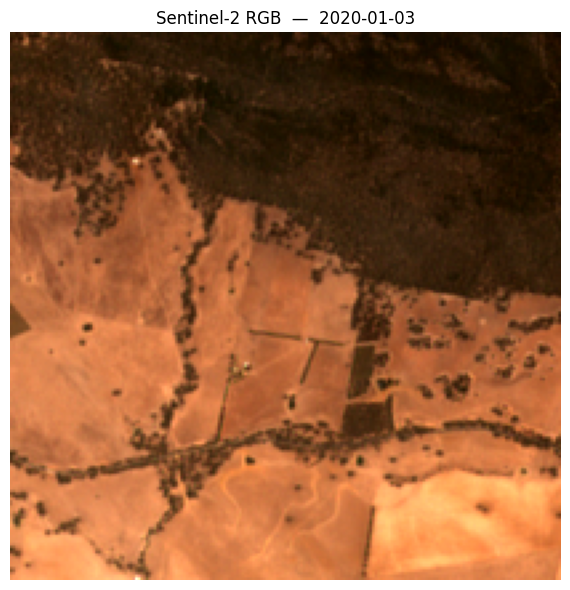

CPU times: user 885 ms, sys: 352 ms, total: 1.24 s
Wall time: 8.94 s


In [5]:
%%time
date_idx = 0
date_str = str(ds.time.values[date_idx])[:10]

red   = ds['nbart_red'].isel(time=date_idx).compute().values.astype(float)
green = ds['nbart_green'].isel(time=date_idx).compute().values.astype(float)
blue  = ds['nbart_blue'].isel(time=date_idx).compute().values.astype(float)

# Stack and normalise to [0, 1] using a simple percentile stretch
rgb = np.stack([red, green, blue], axis=-1)
lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
rgb = np.clip((rgb - lo) / (hi - lo), 0, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rgb)
ax.set_title(f"Sentinel-2 RGB  —  {date_str}")
ax.axis('off')
plt.tight_layout()
plt.show()

## Save to disk

``download_ds2`` wraps the search + load steps above and pickles the result
so the same file can be opened later without re-downloading.

In [6]:
%%time
ds = download_ds2(tif, start_date=start_date, end_date=end_date)

Saved ./g2_26729_binary_tree_cover_10m_ds2_2020.pkl
CPU times: user 624 ms, sys: 26.6 ms, total: 650 ms
Wall time: 1.23 s
